In [8]:
import Pkg; Pkg.activate("/Users/heerakbanerjee/Documents/Newtrinos.jl/devenv/"); Pkg.resolve(); Pkg.instantiate(); Pkg.precompile()

  Activating project at `~/Documents/Newtrinos.jl/devenv`
  No Changes to `~/Documents/Newtrinos.jl/devenv/Project.toml`
  No Changes to `~/Documents/Newtrinos.jl/devenv/Manifest.toml`
Precompiling project...
  13781.8 ms  ✓ Newtrinos
  1 dependency successfully precompiled in 16 seconds. 586 already precompiled.
  1 dependency precompiled but a different version is currently loaded. Restart julia to access the new version. Otherwise, loading dependents of this package may trigger further precompilation to work with the unexpected version.
  1 dependency had output during precompilation:
┌ Newtrinos
│  [ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0xc0227506726a3d45, 0xd0db12282970a28c, 0xab20ed0fb5f464c8, 0x3819f0d3d11f6e76, 0xec3adbf6d7218114, 0xa92180740ed41893, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())
└  


In [9]:
using Revise
using Newtrinos
#using CairoMakie
using Plots

**Test coherent_lar**

┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:68
┌ Info: Initial SS background normalization: 3152.0001600000014
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:102


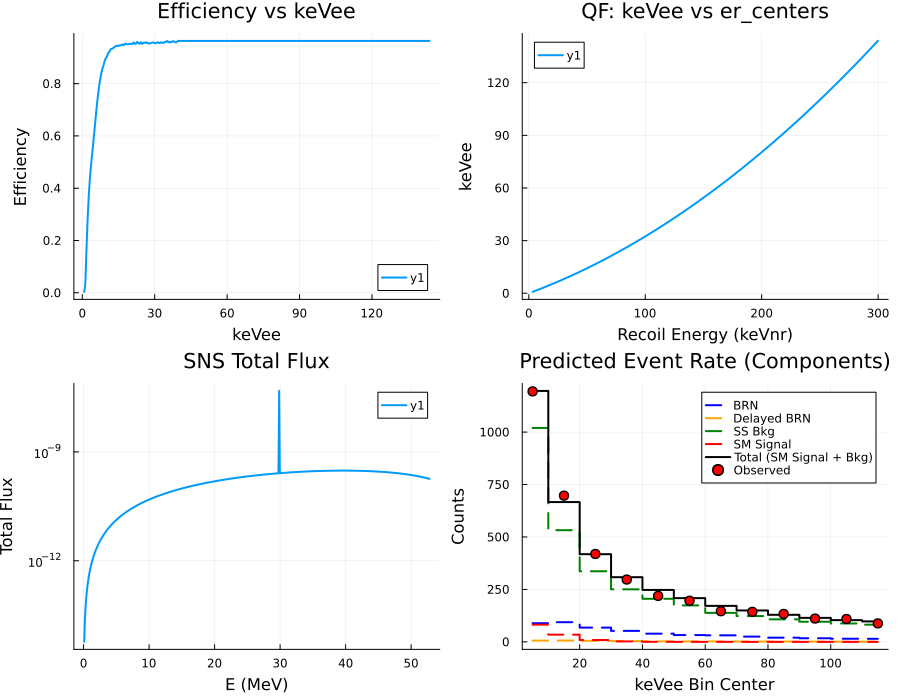

Total expected signal counts: 127.21792023654889

┌ Info: Initial BRN background normalization: 496.99999306999996
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:104
┌ Info: Initial delBRN background normalization: 33.00001642
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:106



Total BRN background counts: 496.99999306999996
Total Delayed BRN background counts: 33.00001642
Total SS background counts: 3152.0001600000014


In [6]:
physics = (sns_flux = Newtrinos.sns_flux.configure(),)
e = Newtrinos.coherent_lAr.configure(physics)
p = Newtrinos.get_params(e)

er_centers = e.assets.er_centers
keVee = Newtrinos.coherent_lAr.qf(er_centers, p)
eff_vals = Newtrinos.coherent_lAr.eff(keVee, e.assets)

flux_result = e.physics.sns_flux.flux(exposure=e.assets.exposure, distance=e.assets.distance)
E = flux_result.E
flux_total = flux_result.total_flux

expected_counts = Newtrinos.coherent_lAr.get_expected(p, e.physics, e.assets)
out_centers = e.assets.out_centers

# Backgrounds
bkg_brn, bkg_delbrn, bkg_ss_bkg = Newtrinos.coherent_lAr.get_backgrounds(p, e.assets)

signal_cum = bkg_brn .+ bkg_delbrn .+ bkg_ss_bkg .+ expected_counts

# Define the first three plots
plt1 = plot(keVee, eff_vals, xlabel="keVee", ylabel="Efficiency", title="Efficiency vs keVee", lw=2)
plt2 = plot(er_centers, keVee, xlabel="Recoil Energy (keVnr)", ylabel="keVee", title="QF: keVee vs er_centers", lw=2)
plt3 = plot(E, flux_total, xlabel="E (MeV)", ylabel="Total Flux", title="SNS Total Flux", lw=2, yscale=:log10)

# Individual components as bars, total as solid line, others as dashed
plt4 = plot()  # Start with empty plot

# Individual components as dashed step plots, separate colors
plot!(plt4, out_centers, bkg_brn, label="BRN", seriestype=:stepmid, color=:blue, lw=2, linestyle=:dash)
plot!(plt4, out_centers, bkg_delbrn, label="Delayed BRN", seriestype=:stepmid, color=:orange, lw=2, linestyle=:dash)
plot!(plt4, out_centers, bkg_ss_bkg, label="SS Bkg", seriestype=:stepmid, color=:green, lw=2, linestyle=:dash)
plot!(plt4, out_centers, expected_counts, label="SM Signal", seriestype=:stepmid, color=:red, lw=2, linestyle=:dash)

# Total rate as solid step plot, normal line width
plot!(plt4, out_centers, signal_cum, label="Total (SM Signal + Bkg)", seriestype=:stepmid, color=:black, lw=2, linestyle=:solid)

# Observed data as filled circles
plot!(plt4, out_centers, e.assets.observed, seriestype=:scatter, marker=:circle, markersize=5, color=:red, label="Observed")

plot!(plt4, xlabel="keVee Bin Center", ylabel="Counts", title="Predicted Event Rate (Components)", legend=:topright)
plt4 = current()

plot(plt1, plt2, plt3, plt4, layout=(2,2), size=(900,700))
display(current())

println("Total expected signal counts: ", sum(expected_counts))
println("Total BRN background counts: ", sum(bkg_brn))
println("Total Delayed BRN background counts: ", sum(bkg_delbrn))
println("Total SS background counts: ", sum(bkg_ss_bkg))

**Test coherent_csi**

┌ Info: Loading coherent csi data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:77
┌ Info: Initial SS background normalization: 4006.0
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:111


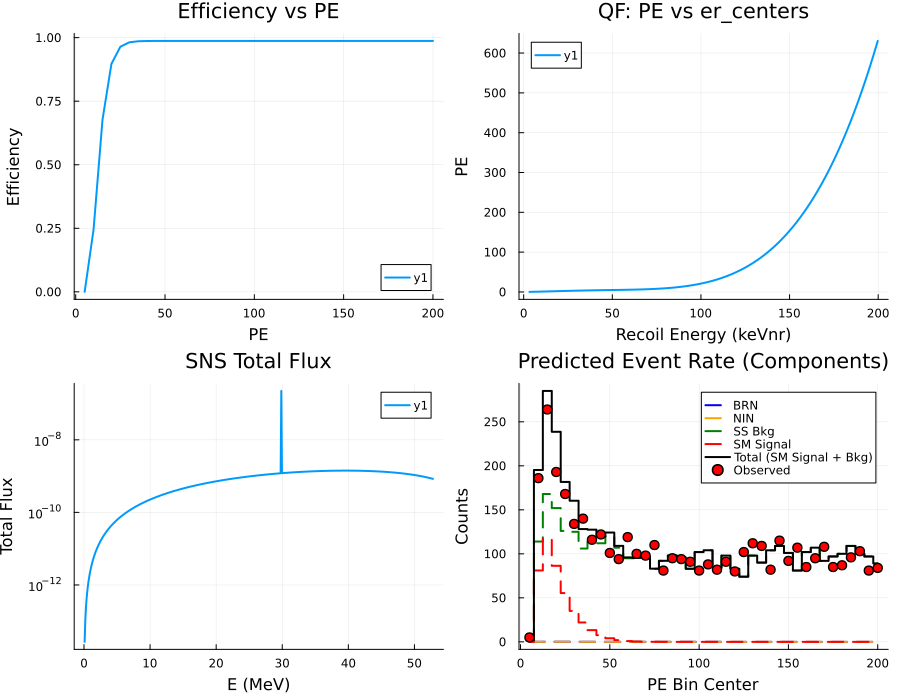

Total expected signal counts: 425.0251798954196

┌ Info: Initial BRN background normalization: 1.4694714
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:113
┌ Info: Initial NIN background normalization: 1.3192349840000002
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:115



Total BRN background counts: 1.4694714
Total NIN background counts: 1.3192349840000002
Total SS background counts: 4006.0


In [7]:
physics = (sns_flux = Newtrinos.sns_flux.configure(),)
e = Newtrinos.coherent_csi.configure(physics)
p = Newtrinos.get_params(e)

er_centers = e.assets.er_centers
pe_centers = e.assets.out_centers

# Efficiency and QF (if available)
eff_vals = Newtrinos.coherent_csi.eff(pe_centers, e.params)
qf_vals = Newtrinos.coherent_csi.qf(er_centers, p)

flux_result = e.physics.sns_flux.flux(exposure=e.assets.exposure, distance=e.assets.distance)
E = flux_result.E
flux_total = flux_result.total_flux

expected_counts = Newtrinos.coherent_csi.get_expected(p, e.physics, e.assets)

# Backgrounds
bkg_brnPE, bkg_ninPE, bkg_ssBkg = Newtrinos.coherent_csi.get_backgrounds(p, e.assets)

signal_cum = bkg_brnPE .+ bkg_ninPE .+ bkg_ssBkg .+ expected_counts

# Define the first three plots
plt1 = plot(pe_centers, eff_vals, xlabel="PE", ylabel="Efficiency", title="Efficiency vs PE", lw=2)
plt2 = plot(er_centers, qf_vals, xlabel="Recoil Energy (keVnr)", ylabel="PE", title="QF: PE vs er_centers", lw=2)
plt3 = plot(E, flux_total, xlabel="E (MeV)", ylabel="Total Flux", title="SNS Total Flux", lw=2, yscale=:log10)

# Individual components as bars, total as solid line, others as dashed
plt4 = plot()  # Start with empty plot

# Individual components as dashed step plots, separate colors
plot!(plt4, pe_centers, bkg_brnPE, label="BRN", seriestype=:stepmid, color=:blue, lw=2, linestyle=:dash)
plot!(plt4, pe_centers, bkg_ninPE, label="NIN", seriestype=:stepmid, color=:orange, lw=2, linestyle=:dash)
plot!(plt4, pe_centers, bkg_ssBkg, label="SS Bkg", seriestype=:stepmid, color=:green, lw=2, linestyle=:dash)
plot!(plt4, pe_centers, expected_counts, label="SM Signal", seriestype=:stepmid, color=:red, lw=2, linestyle=:dash)

# Total rate as solid step plot, normal line width
plot!(plt4, pe_centers, signal_cum, label="Total (SM Signal + Bkg)", seriestype=:stepmid, color=:black, lw=2, linestyle=:solid)

# Observed data as filled circles
plot!(plt4, pe_centers, e.assets.observed, seriestype=:scatter, marker=:circle, markersize=5, color=:red, label="Observed")

plot!(plt4, xlabel="PE Bin Center", ylabel="Counts", title="Predicted Event Rate (Components)", legend=:topright)
plt4 = current()

plot(plt1, plt2, plt3, plt4, layout=(2,2), size=(900,700))
display(current())

println("Total expected signal counts: ", sum(expected_counts))
println("Total BRN background counts: ", sum(bkg_brnPE))
println("Total NIN background counts: ", sum(bkg_ninPE))
println("Total SS background counts: ", sum(bkg_ssBkg))

**Test Parameter Dependence**

*Liquid Ar [CENNS10]*

┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:68
┌ Info: Initial SS background normalization: 3152.0001600000014
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:102
┌ Info: Initial BRN background normalization: 496.99999306999996
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:104
┌ Info: Initial delBRN background normalization: 33.00001642
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:106


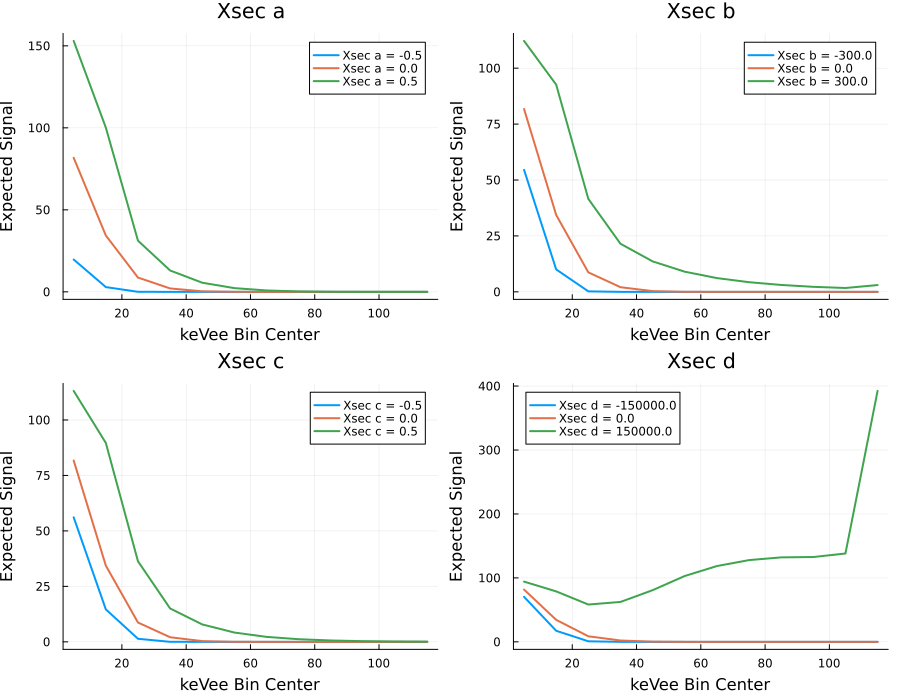

In [14]:
# lAr: 2x2 plot palette for expected signal vs out_centers, varying cevns_xsec_a, b, c, d in [-1, 1]

physics = (sns_flux = Newtrinos.sns_flux.configure(),)
e = Newtrinos.coherent_lAr.configure(physics)
p_nom = Newtrinos.get_params(e)
out_centers = e.assets.out_centers

param_syms = [:cevns_xsec_a, :cevns_xsec_b, :cevns_xsec_c, :cevns_xsec_d]
param_labels = ["Xsec a", "Xsec b", "Xsec c", "Xsec d"]
param_scales = [0.5, 3e2, 0.5, 1.5e5]  # scaling for a, b, c, d

plots = []
for (i, sym) in enumerate(param_syms)
    plt = plot()  # Initialize a new plot for each parameter
    for val in [-1.0, 0.0, 1.0]
        p = deepcopy(p_nom)
        p = merge(p, (sym => val * param_scales[i],))
        label_str = param_scales[i] == 1 ? "$(param_labels[i]) = $val" : "$(param_labels[i]) = $(val * param_scales[i])"
        plot!(plt, out_centers, Newtrinos.coherent_lAr.get_expected(p, e.physics, e.assets), label=label_str, lw=2)
    end
    plot!(plt, xlabel="keVee Bin Center", ylabel="Expected Signal", title=param_labels[i])
    push!(plots, plt)
end
plot(plots..., layout=(2,2), size=(900,700))

vals[1:10] = [0.0, 81.0963505878529, 116.82152971430298, 86.38712740967692, 55.41019054183535, 35.130602285718915, 21.992902645121838, 13.29752125943199, 7.604036781400938, 4.033720971377558]

┌ Info: Loading coherent csi data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:77
┌ Info: Initial SS background normalization: 4006.0
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:111
┌ Info: Initial BRN background normalization: 1.4694714
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:113
┌ Info: Initial NIN background normalization: 1.3192349840000002
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:115



sum(vals) = 425.072954822021
vals[1:10] = [0.0, 81.0963505878529, 116.82152971430298, 86.38712740967692, 55.41019054183535, 35.130602285718915, 21.992902645121838, 13.29752125943199, 7.604036781400938, 4.033720971377558]
sum(vals) = 425.072954822021
vals[1:10] = [0.0, 81.0963505878529, 116.82152971430298, 86.38712740967692, 55.41019054183535, 35.130602285718915, 21.992902645121838, 13.29752125943199, 7.604036781400938, 4.033720971377558]
sum(vals) = 425.072954822021
vals[1:10] = [0.0, 81.0963505878529, 116.82152971430298, 86.38712740967692, 55.41019054183535, 35.130602285718915, 21.992902645121838, 13.29752125943199, 7.604036781400938, 4.033720971377558]
sum(vals) = 425.072954822021


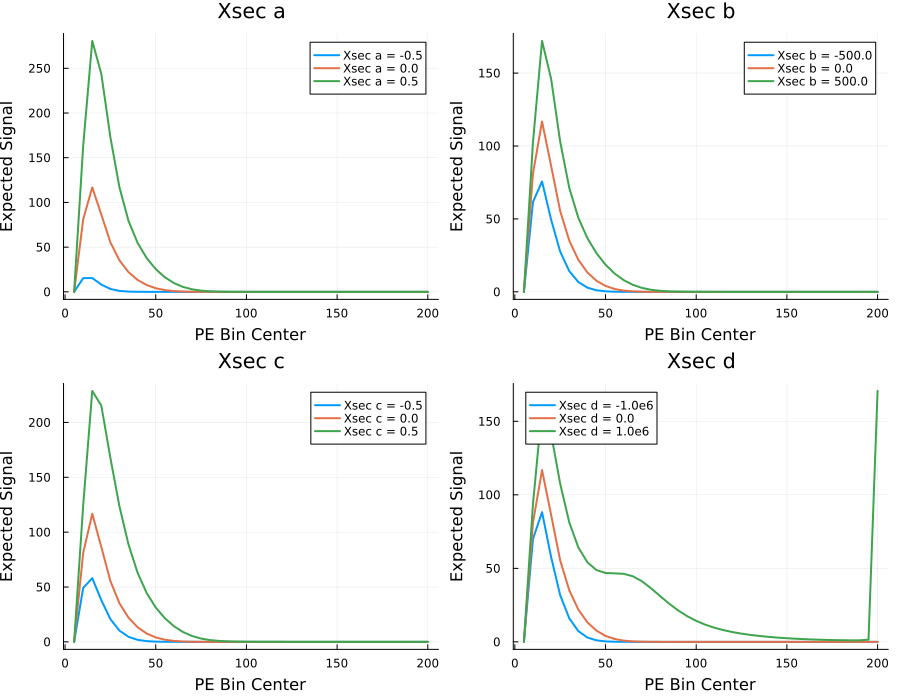

In [11]:
# CsI: 2x2 plot palette for expected signal vs out_centers, scaling b and d for testing

physics = (sns_flux = Newtrinos.sns_flux.configure(),)
e = Newtrinos.coherent_csi.configure(physics)
p_nom = Newtrinos.get_params(e)
out_centers = e.assets.out_centers

param_syms = [:cevns_xsec_a, :cevns_xsec_b, :cevns_xsec_c, :cevns_xsec_d]
param_labels = ["Xsec a", "Xsec b", "Xsec c", "Xsec d"]
param_scales = [0.5, 5e2, 0.5, 1e6]  # scaling for a, b, c, d

plots = []
for (i, sym) in enumerate(param_syms)
    plt = plot()  # Initialize a new plot for each parameter
    for val in [-1.0, 0.0, 1.0]
        p = deepcopy(p_nom)
        p = merge(p, (sym => val * param_scales[i],))
        label_str = param_scales[i] == 1 ? "$(param_labels[i]) = $val" : "$(param_labels[i]) = $(val * param_scales[i])"
        vals = Newtrinos.coherent_csi.get_expected(p, e.physics, e.assets)
        plot!(plt, out_centers, vals, label=label_str, lw=2)
    end
    plot!(plt, xlabel="PE Bin Center", ylabel="Expected Signal", title=param_labels[i])
    push!(plots, plt)
    vals = Newtrinos.coherent_csi.get_expected(p_nom, e.physics, e.assets)
    @show vals[1:10]
    @show sum(vals)
end
plot(plots..., layout=(2,2), size=(900,700))

**Scan Likelihoods**

┌ Info: Loading coherent csi data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:77
┌ Info: Initial SS background normalization: 4006.0
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:111
┌ Info: Initial BRN background normalization: 1.4694714
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:113
┌ Info: Initial NIN background normalization: 1.3192349840000002
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:115
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel re

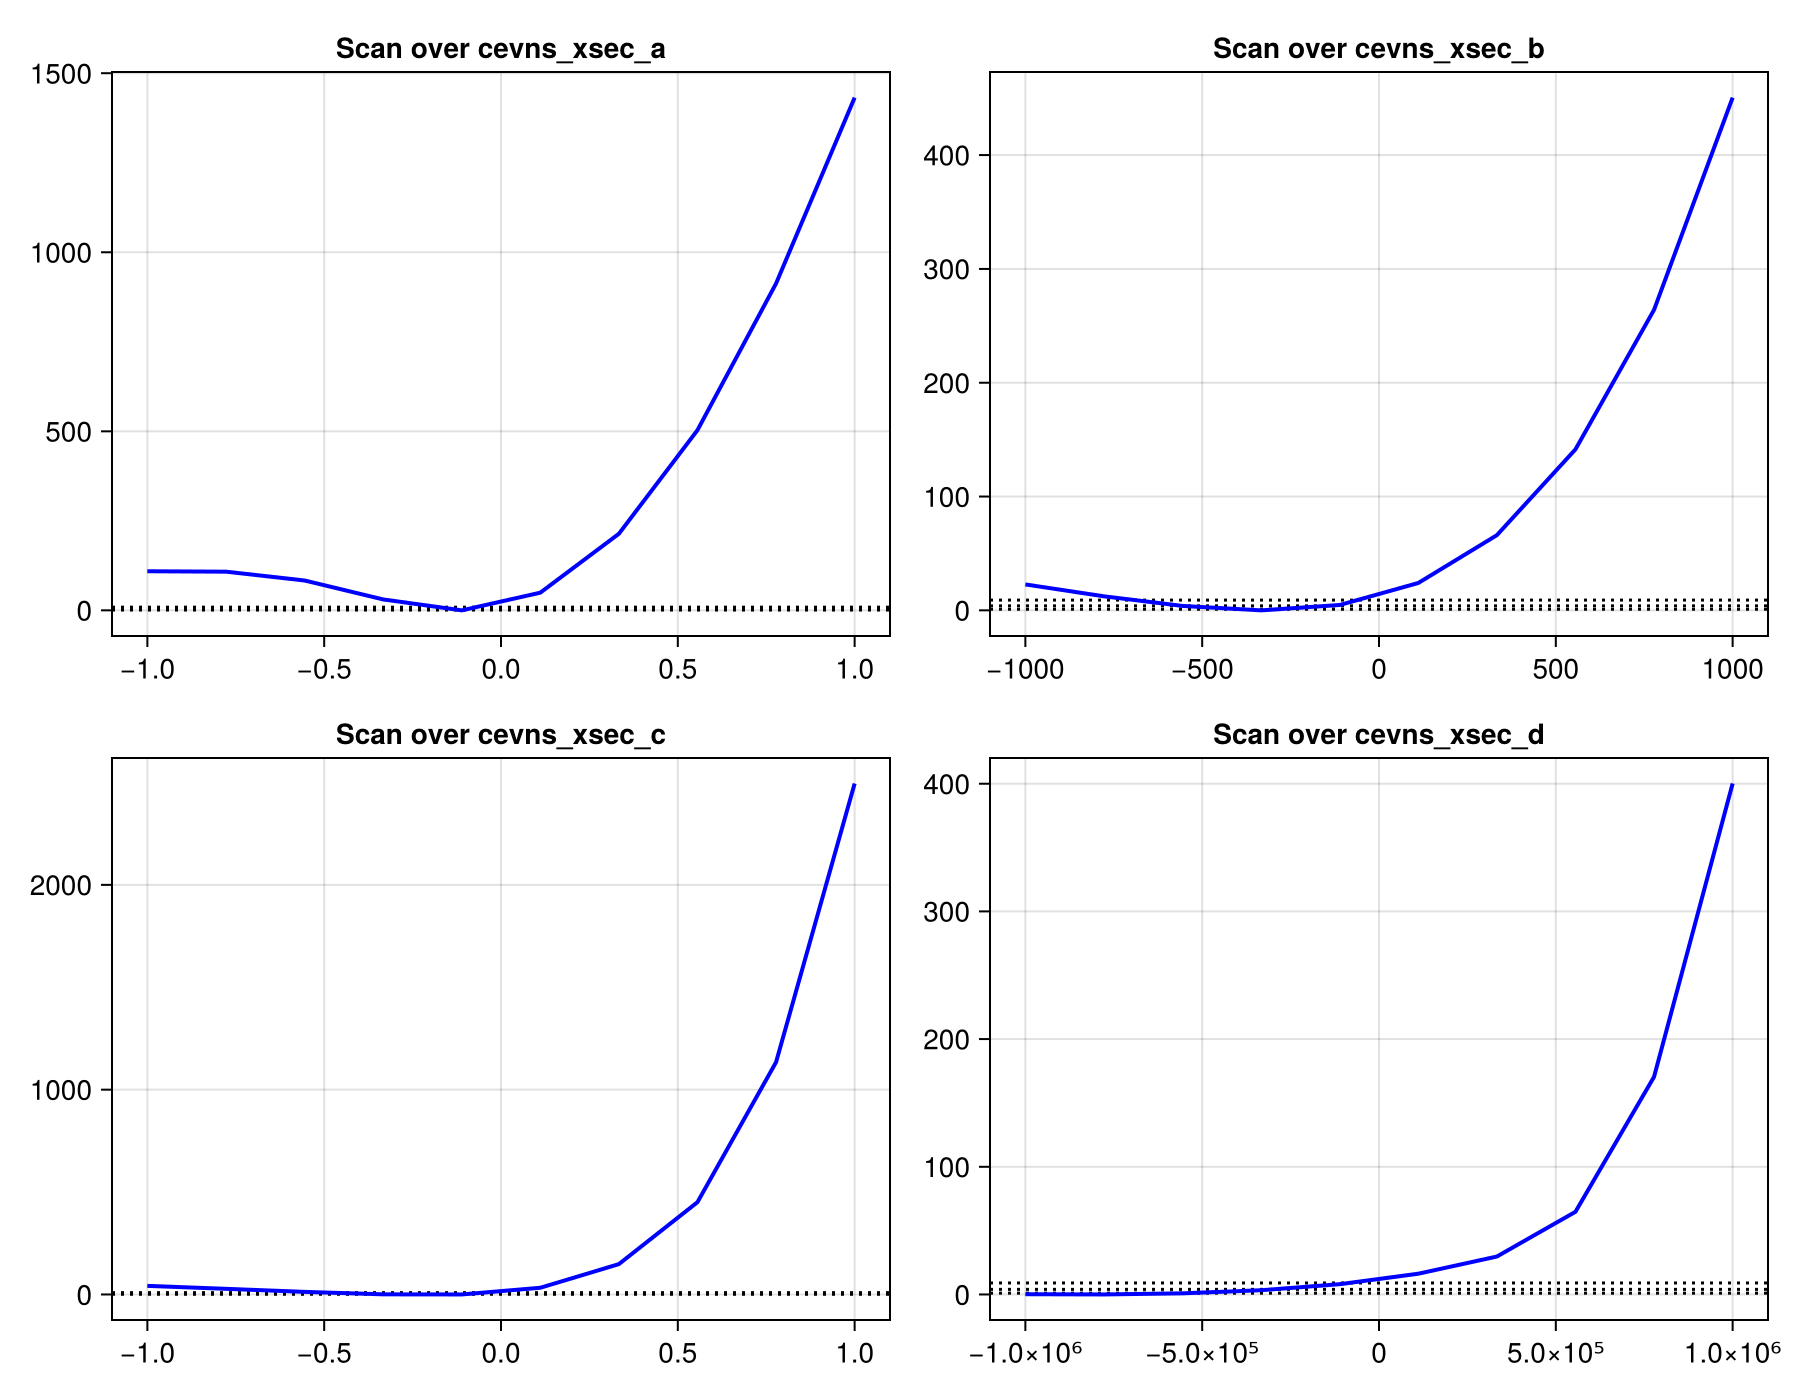

In [12]:
using CairoMakie
physics = (; sns_flux = Newtrinos.sns_flux.configure())
experiments = (;coherent_csi = Newtrinos.coherent_csi.configure(physics))
likelihood = Newtrinos.generate_likelihood(experiments)
p = Newtrinos.get_params(experiments)
priors = Newtrinos.get_priors(experiments)

scan_params = [
    (:cevns_xsec_a, 10, "Scan over cevns_xsec_a"),
    (:cevns_xsec_b, 10, "Scan over cevns_xsec_b"),
    (:cevns_xsec_c, 10, "Scan over cevns_xsec_c"),
    (:cevns_xsec_d, 10, "Scan over cevns_xsec_d"),
]

fig = Figure(resolution = (900, 700))

for (i, (param, npoints, label)) in enumerate(scan_params)
    row, col = fldmod1(i, 2)   # 2 columns grid
    ax = Axis(fig[row, col], title = label)

    scan_tuple = NamedTuple{(param,)}((npoints,))
    result = Newtrinos.scan(likelihood, priors, scan_tuple, p)

    CairoMakie.plot!(ax, result)  # uses the Newtrinos recipe
end

fig

┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:68
┌ Info: Initial SS background normalization: 3152.0001600000014
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:102
┌ Info: Initial BRN background normalization: 496.99999306999996
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:104
┌ Info: Initial delBRN background normalization: 33.00001642
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:106
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size a

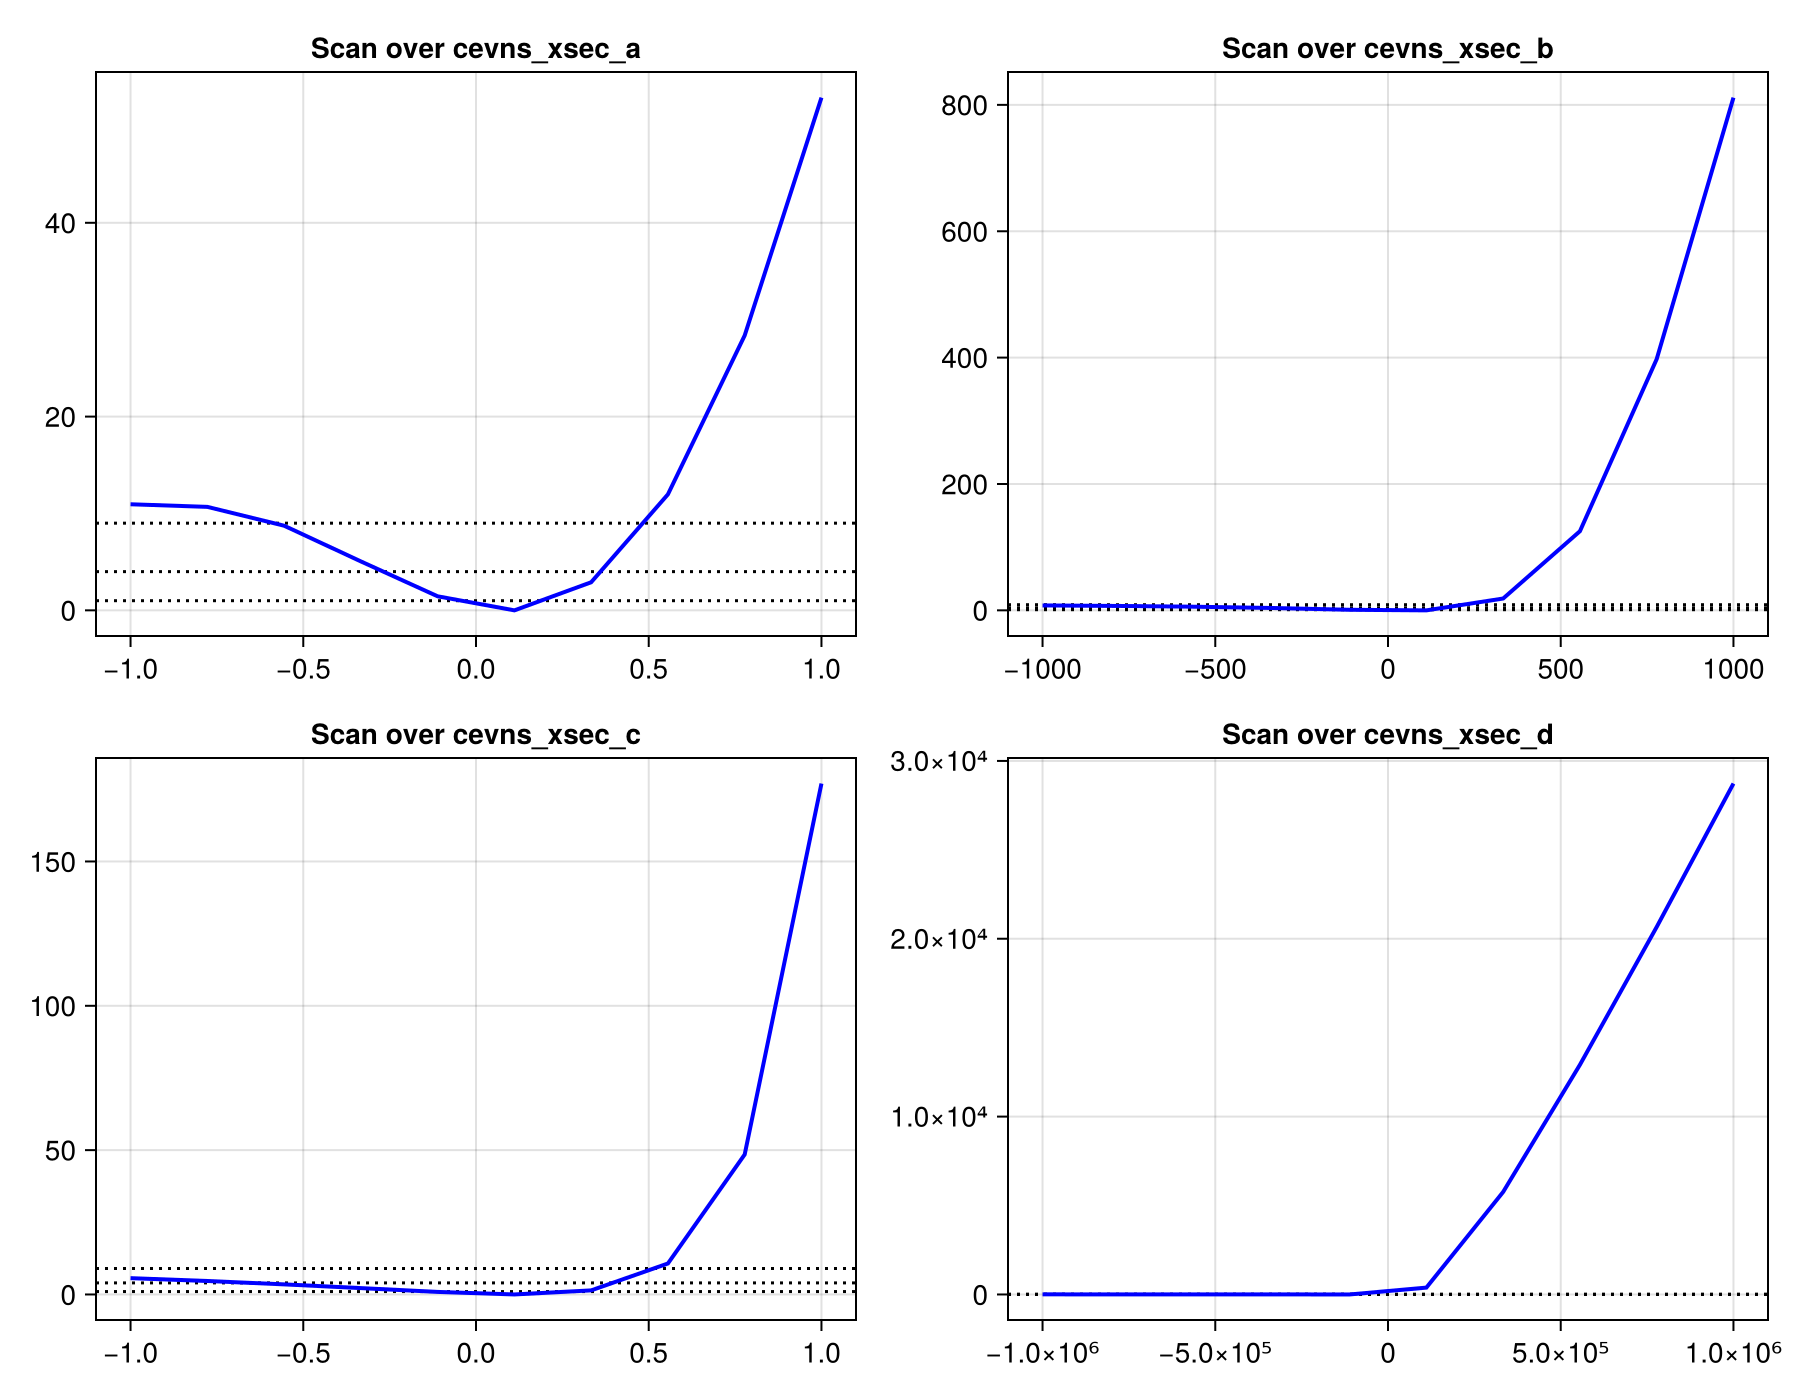

In [15]:
using CairoMakie
physics = (; sns_flux = Newtrinos.sns_flux.configure())
experiments = (;coherent_lAr = Newtrinos.coherent_lAr.configure(physics))
likelihood = Newtrinos.generate_likelihood(experiments)
p = Newtrinos.get_params(experiments)
priors = Newtrinos.get_priors(experiments)

scan_params = [
    (:cevns_xsec_a, 10, "Scan over cevns_xsec_a"),
    (:cevns_xsec_b, 10, "Scan over cevns_xsec_b"),
    (:cevns_xsec_c, 10, "Scan over cevns_xsec_c"),
    (:cevns_xsec_d, 10, "Scan over cevns_xsec_d"),
]

fig = Figure(resolution = (900, 700))

for (i, (param, npoints, label)) in enumerate(scan_params)
    row, col = fldmod1(i, 2)   # 2 columns grid
    ax = Axis(fig[row, col], title = label)

    scan_tuple = NamedTuple{(param,)}((npoints,))
    result = Newtrinos.scan(likelihood, priors, scan_tuple, p)

    CairoMakie.plot!(ax, result)  # uses the Newtrinos recipe
end

fig

┌ Info: Loading coherent csi data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:77
┌ Info: Initial SS background normalization: 4006.0
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:111
┌ Info: Initial BRN background normalization: 1.4694714
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:113
┌ Info: Initial NIN background normalization: 1.3192349840000002
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:115
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel re

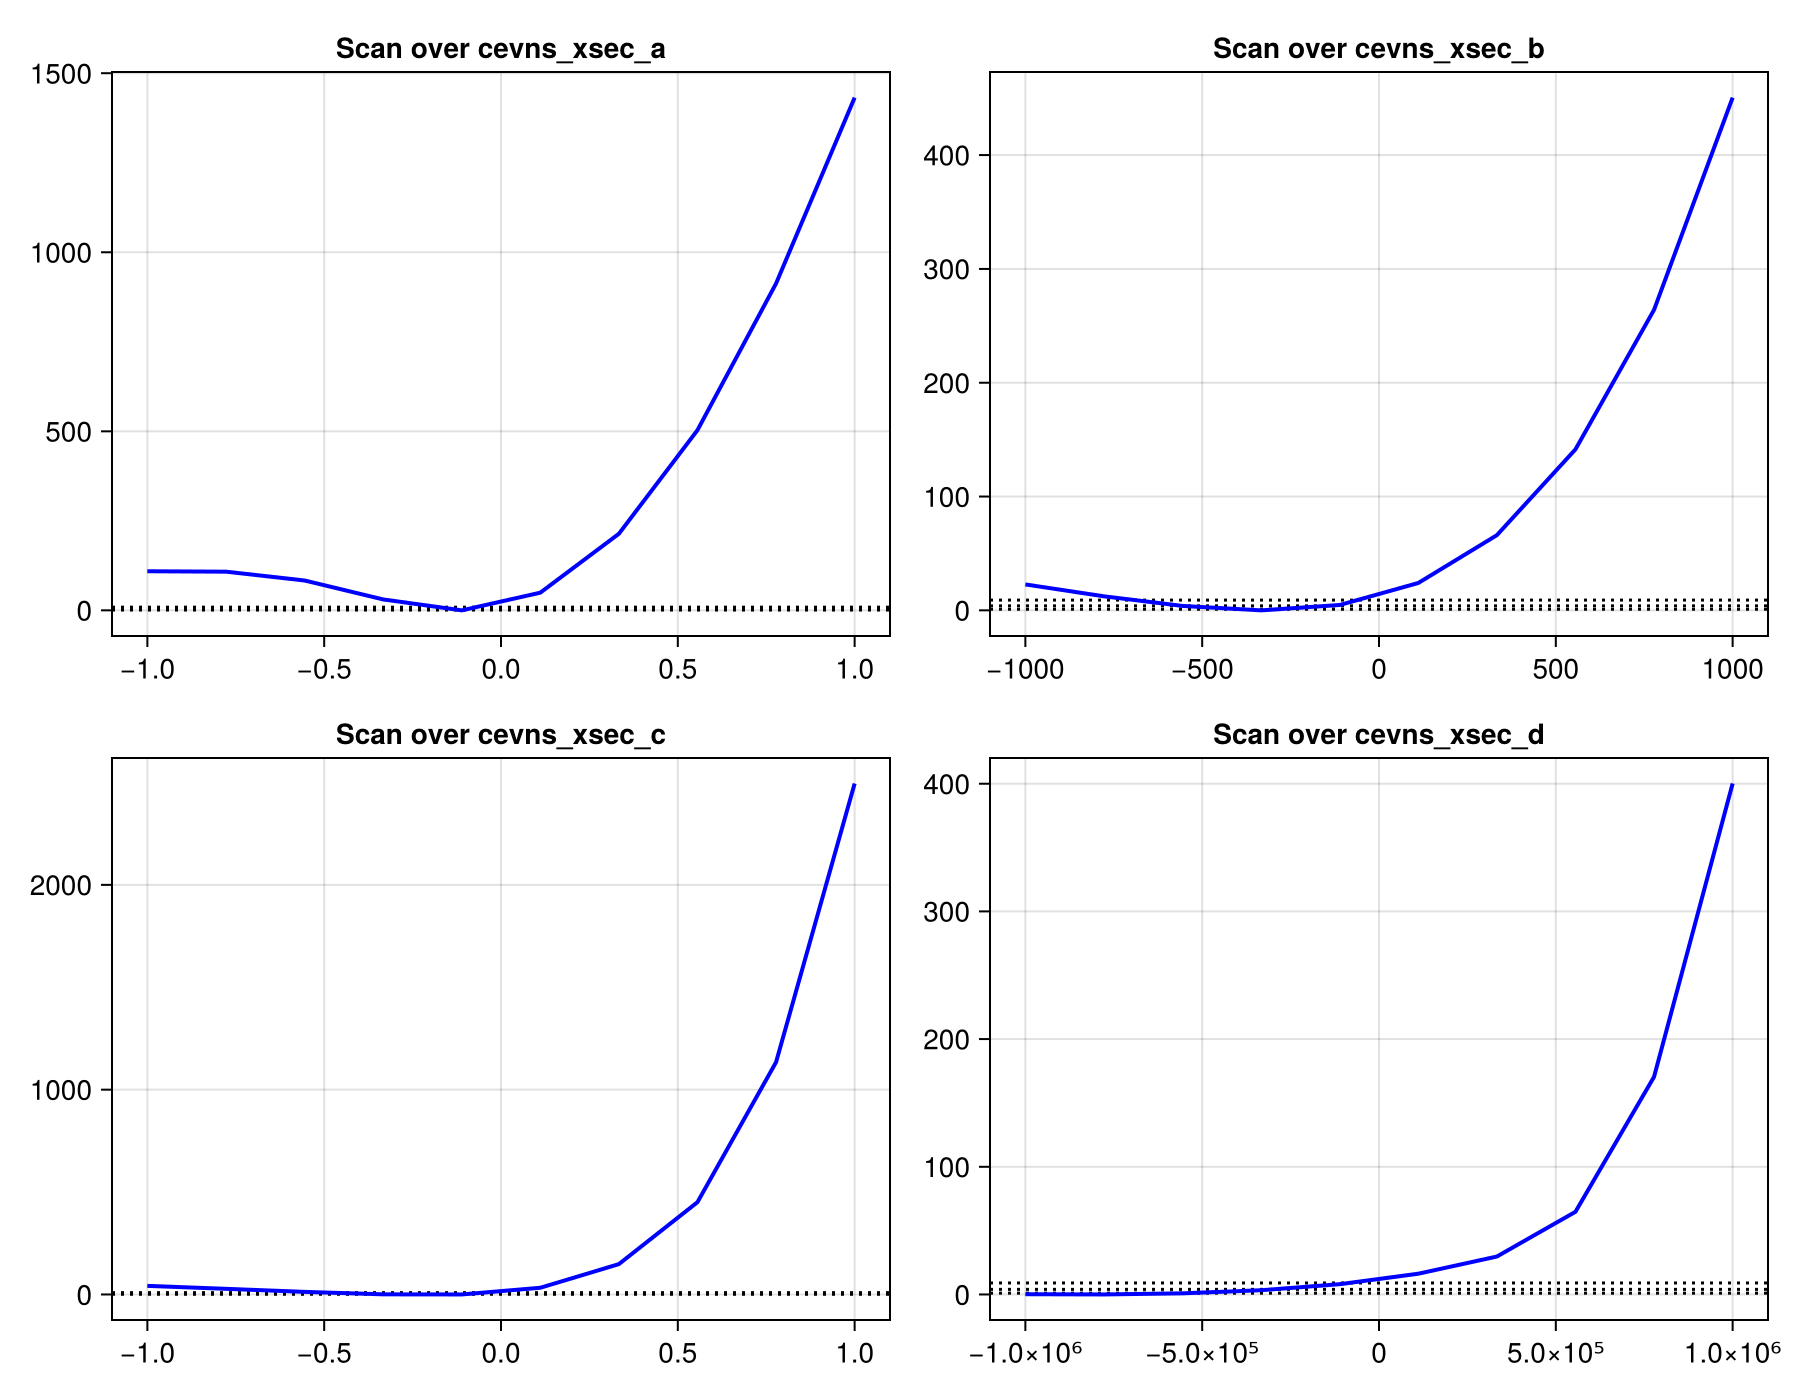

In [13]:
physics = (; sns_flux = Newtrinos.sns_flux.configure())
experiments = (;coherent_csi = Newtrinos.coherent_csi.configure(physics))
likelihood = Newtrinos.generate_likelihood(experiments)
p = Newtrinos.get_params(experiments)
priors = Newtrinos.get_priors(experiments)

scan_params = [
    (:cevns_xsec_a, 10, "Scan over cevns_xsec_a"),
    (:cevns_xsec_b, 10, "Scan over cevns_xsec_b"),
    (:cevns_xsec_c, 10, "Scan over cevns_xsec_c"),
    (:cevns_xsec_d, 10, "Scan over cevns_xsec_d"),
]

fig = Figure(resolution = (900, 700))

for (i, (param, npoints, label)) in enumerate(scan_params)
    row, col = fldmod1(i, 2)   # 2 columns grid
    ax = Axis(fig[row, col], title = label)

    scan_tuple = NamedTuple{(param,)}((npoints,))
    result = Newtrinos.profile(likelihood, priors, scan_tuple, p)

    CairoMakie.plot!(ax, result)  # uses the Newtrinos recipe
end

fig

┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:68
┌ Info: Initial SS background normalization: 3152.0001600000014
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:102
┌ Info: Initial BRN background normalization: 496.99999306999996
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:104
┌ Info: Initial delBRN background normalization: 33.00001642
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:106
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size a

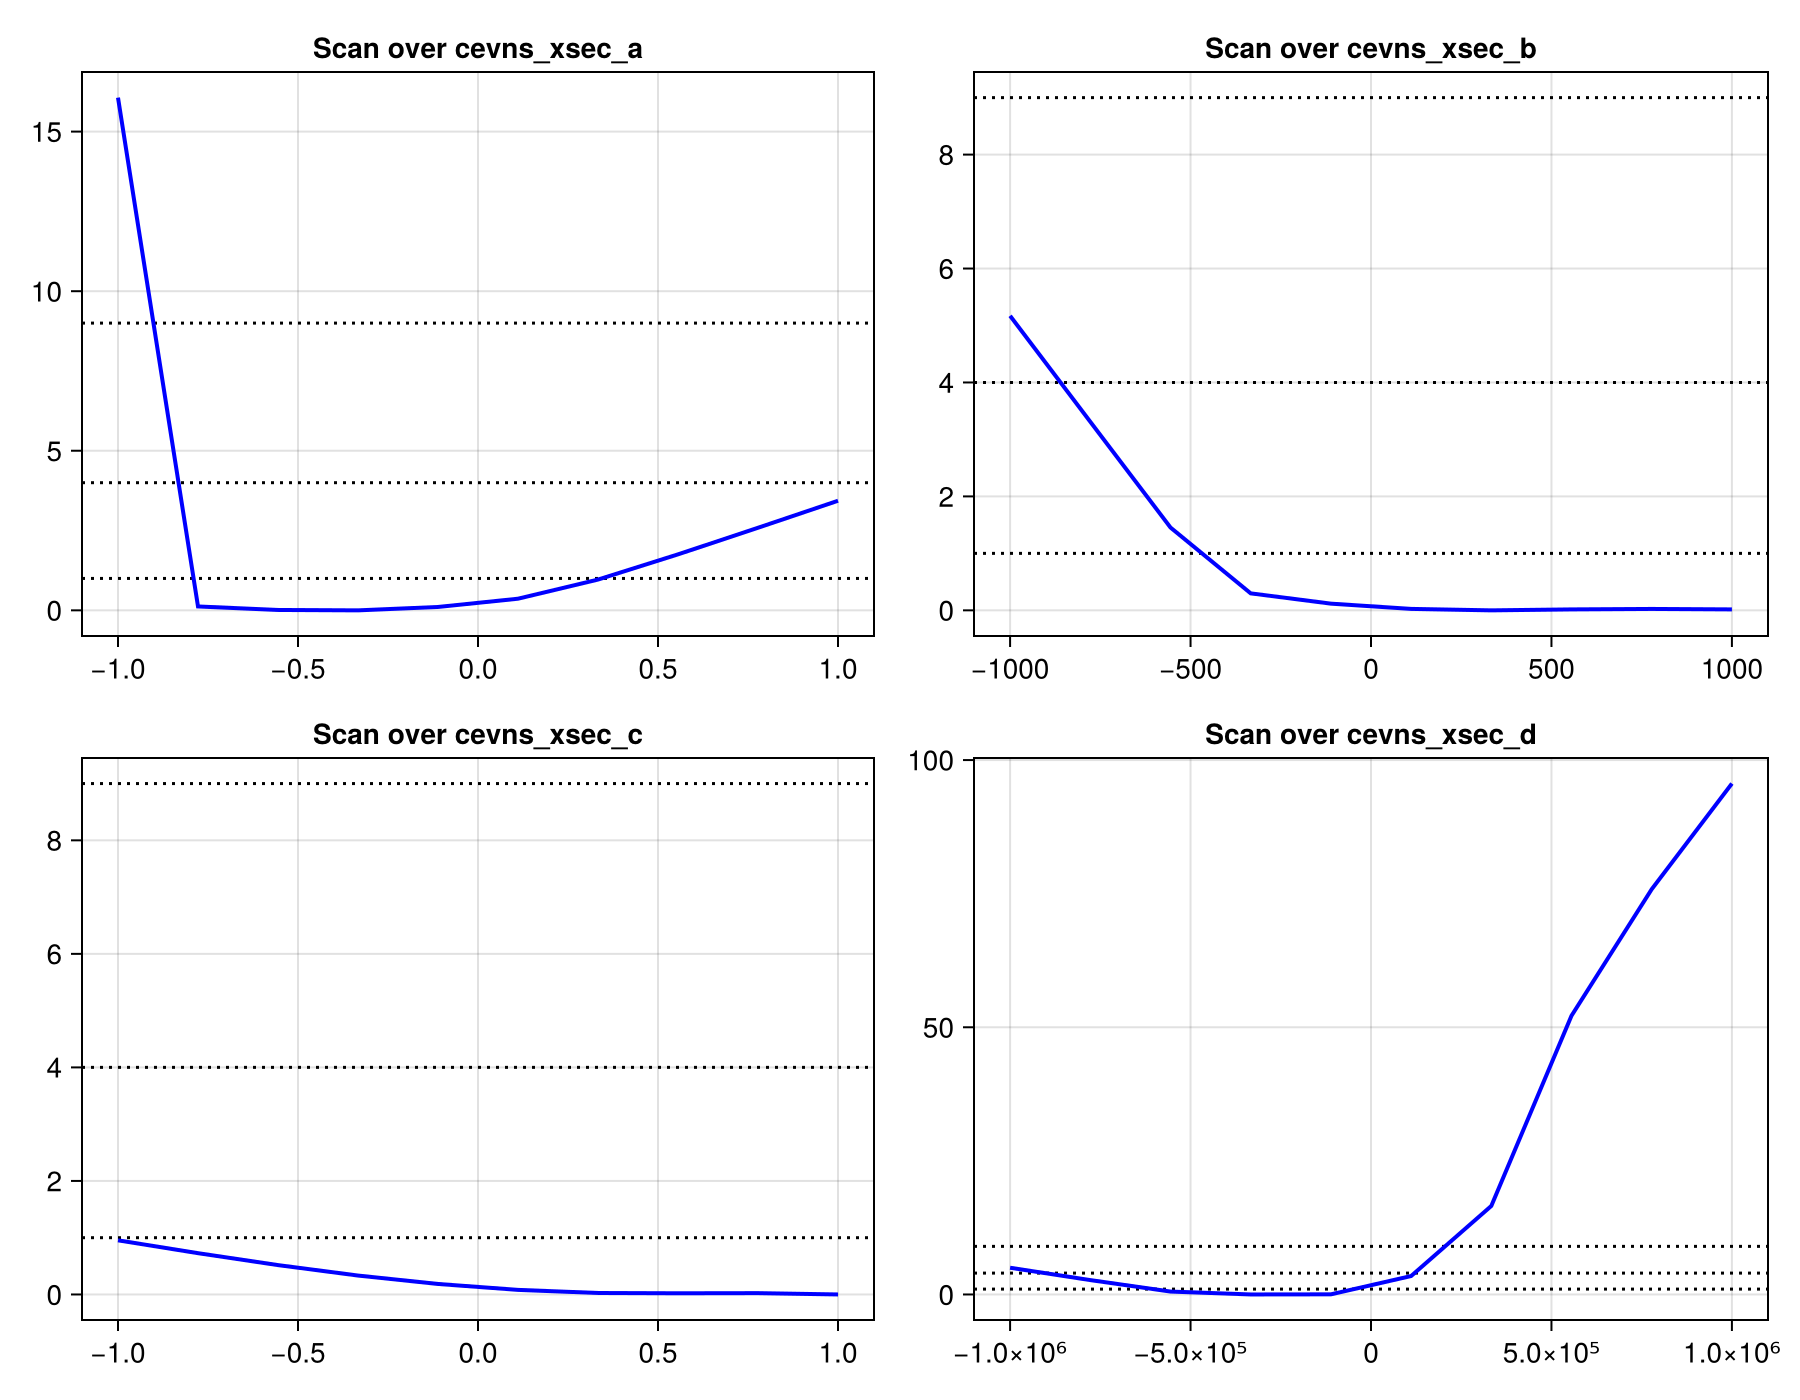

In [16]:
physics = (; sns_flux = Newtrinos.sns_flux.configure())
experiments = (;coherent_lAr = Newtrinos.coherent_lAr.configure(physics))
likelihood = Newtrinos.generate_likelihood(experiments)
p = Newtrinos.get_params(experiments)
priors = Newtrinos.get_priors(experiments)

scan_params = [
    (:cevns_xsec_a, 10, "Scan over cevns_xsec_a"),
    (:cevns_xsec_b, 10, "Scan over cevns_xsec_b"),
    (:cevns_xsec_c, 10, "Scan over cevns_xsec_c"),
    (:cevns_xsec_d, 10, "Scan over cevns_xsec_d"),
]

fig = Figure(resolution = (900, 700))

for (i, (param, npoints, label)) in enumerate(scan_params)
    row, col = fldmod1(i, 2)   # 2 columns grid
    ax = Axis(fig[row, col], title = label)

    scan_tuple = NamedTuple{(param,)}((npoints,))
    result = Newtrinos.profile(likelihood, priors, scan_tuple, p)

    CairoMakie.plot!(ax, result)  # uses the Newtrinos recipe
end

fig